In [1]:
import pandas as pd
import numpy as np
from datetime import datetime

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

# 한글 폰트 설정
plt.rc("font", family="Malgun Gothic")
plt.rc("axes", unicode_minus=False)

pd.set_option("display.max_columns", 50)

# 데이터 로드  
> vworld의 중개사 + 피터팬 크롤링 크롤링 중개사 매칭한 데이터

In [9]:
# 데이터 로드
clean_path = "../../../../data/seoul_broker_clean.csv"
df = pd.read_csv(clean_path)

print("="*50)
print("데이터 기본 정보")
print("="*50)
print(f"\n데이터 크기: {df.shape[0]}행 x {df.shape[1]}열")
print(f"\n컬럼 목록:\n{df.columns.tolist()}")
print(f"\n데이터 타입:\n{df.dtypes}")
print(f"\n기본 통계:\n{df.describe()}")
print(f"\n결측치 정보:\n{df.isnull().sum()}")
df.head()

데이터 기본 정보

데이터 크기: 380행 x 13열

컬럼 목록:
['jurirno', 'brkrNm', 'ldCodeNm', 'registDe', 'mnnmadr', 'estbsBeginDe', 'estbsEndDe', 'sttusSeCode', 'bsnmCmpnm', '등록번호', '거래완료', '등록매물', '총매물수']

데이터 타입:
jurirno         object
brkrNm          object
ldCodeNm        object
registDe        object
mnnmadr         object
estbsBeginDe    object
estbsEndDe      object
sttusSeCode      int64
bsnmCmpnm       object
등록번호            object
거래완료             int64
등록매물             int64
총매물수             int64
dtype: object

기본 통계:
       sttusSeCode           거래완료        등록매물           총매물수
count        380.0     380.000000  380.000000     380.000000
mean           1.0    8003.092105   50.065789    8053.157895
std            0.0   35495.157061   77.796625   35543.811252
min            1.0       0.000000    0.000000       0.000000
25%            1.0      24.000000   10.000000      47.500000
50%            1.0     358.000000   21.000000     389.500000
75%            1.0    2310.000000   58.250000    2374.7500

,jurirno,brkrNm,ldCodeNm,registDe,mnnmadr,estbsBeginDe,estbsEndDe,sttusSeCode,bsnmCmpnm,등록번호,거래완료,등록매물,총매물수
0,11620-2021-00004,김대환,서울특별시 관악구,2021-01-07,서울특별시 관악구 봉천동 961-2,2025-01-08,2026-01-07,1,대한공인중개사사무소,11620-2021-00004,2530,100,2630
1,11620-2024-00006,박지애,서울특별시 관악구,2024-01-10,서울특별시 관악구 신림동 476-11,2025-01-12,2026-01-11,1,The태양공인중개사사무소,11620-2024-00006,950,45,995
2,가3622-05-168,김미정,서울특별시 광진구,2005-10-25,서울특별시 광진구 구의동 254-30,2025-07-22,2026-07-21,1,재테크부동산공인중개사사무소,가3622-05-168,224,10,234
3,11470-2022-00111,하임리나,서울특별시 양천구,2022-11-18,서울특별시 양천구 신월동 341-1,2025-11-21,2026-11-20,1,평강부동산공인중개사사무소,11470-2022-00111,1536,28,1564
4,11590-2015-00090,정종원,서울특별시 관악구,2015-06-18,서울특별시 관악구 봉천동 893-12,2025-06-18,2026-06-17,1,부동산포커스공인중개사사무소,11590201500090,99,30,129


> **컬럼**  
>
>    - jurirno: 등록번호  
>    - brkrNm: 중개사 이름  
>    - ldCodeNm: 지역명 (구 단위)  
>    - registDe: 영업시작 일자  
>    - mnnmadr: 소재지  
>    - estbsBeginDe: 보증보험 시작일  
>    - estbsEndDe: 보증보험 종료일  
>    - sttusSeCode: 상태코드 (1: 정상영업중)  
>    - bsnmCmpnm: 중개사무소 상호명  
>    - 등록번호: 중개사 등록번호 (jurirno와 동일)  
>    - 거래완료: 지금까지 거래 완료한 매물 수  
>    - 등록매물: 현재 등록되어있는 매물 수  
>    - 총매물수: 거래완료 + 등록매물  



# EDA_v1

## 기본 통계 & 분포 확인

수치형 컬럼: ['sttusSeCode', '거래완료', '등록매물', '총매물수']


C:\Users\Playdata\AppData\Local\Temp\ipykernel_980\2860941225.py:7: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
C:\Users\Playdata\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


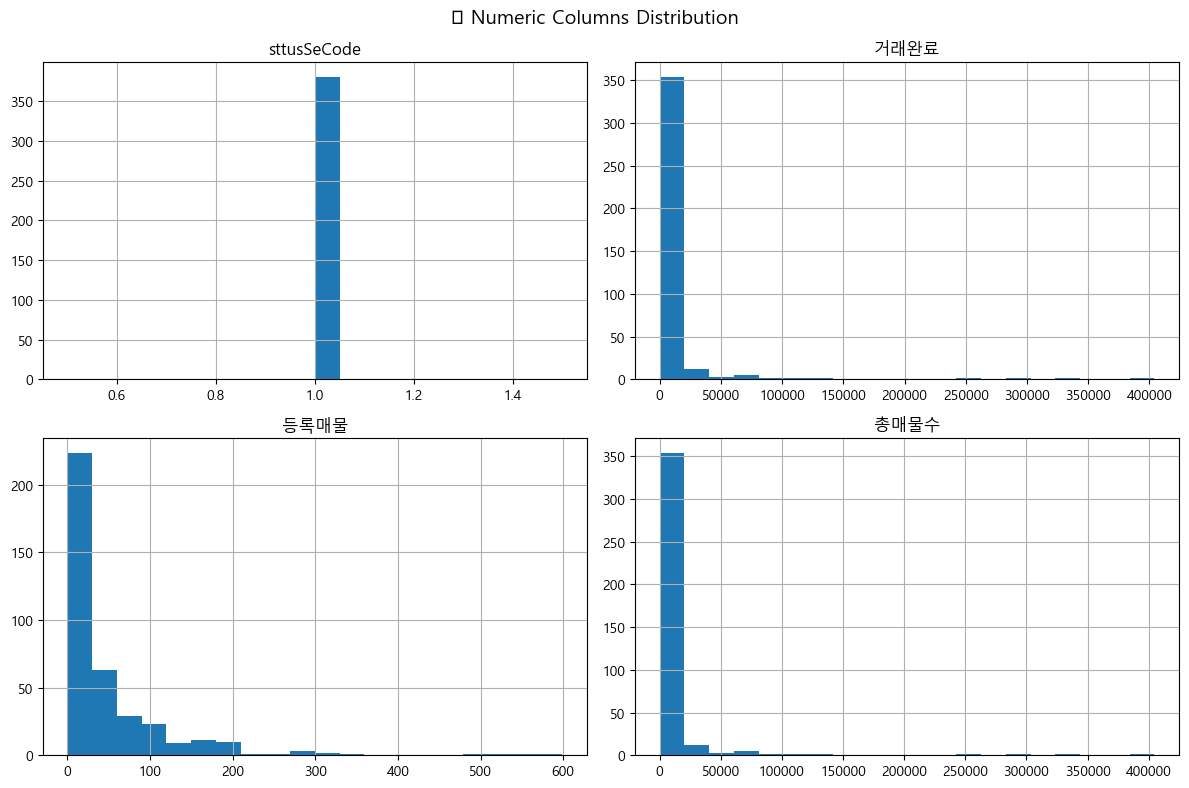


 describe(include='all') 결과


,jurirno,brkrNm,ldCodeNm,registDe,mnnmadr,estbsBeginDe,estbsEndDe,sttusSeCode,bsnmCmpnm,등록번호,거래완료,등록매물,총매물수
count,380,380,380,380,380,380,380,380.0,380,380,380.000000,380.000000,380.000000
unique,380,377,25,343,372,237,237,NaN,346,370,NaN,NaN,NaN
top,11620-2021-00004,이선우,서울특별시 관악구,2023-04-17,서울특별시 강남구 역삼동 825-20,2025-01-03,2026-01-02,NaN,바른공인중개사사무소,11650-2022-00036,NaN,NaN,NaN
freq,1,2,69,3,3,7,7,NaN,4,3,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,8003.092105,50.065789,8053.157895
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,35495.157061,77.796625,35543.811252
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,0.000000,0.000000,0.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,24.000000,10.000000,47.500000
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,358.000000,21.000000,389.500000
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,2310.000000,58.250000,2374.750000


In [10]:
# 전체 히스토그램 (수치형 컬럼만)
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns
print(f"수치형 컬럼: {numeric_cols.tolist()}")

df[numeric_cols].hist(figsize=(12, 8), bins=20)
plt.suptitle("📊 Numeric Columns Distribution", fontsize=14)
plt.tight_layout()
plt.show()

# 요약통계
print("\n describe(include='all') 결과")
display(df.describe(include='all'))


## 거래 성사율(success_rate) 분석


📈 success_rate 기본 통계
count    380.000000
mean       0.741578
std        0.353438
min        0.000000
25%        0.615385
50%        0.934496
75%        0.985430
max        0.999279
Name: success_rate, dtype: float64


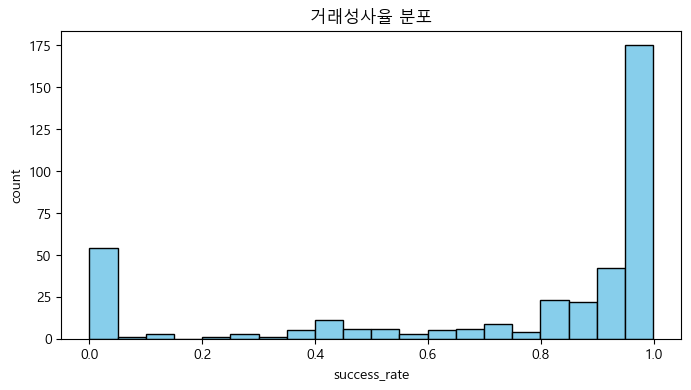


 <지역별 평균> success_rate


ldCodeNm
서울특별시 중구      0.939781
서울특별시 동작구     0.908646
서울특별시 은평구     0.885635
서울특별시 마포구     0.870775
서울특별시 구로구     0.844063
서울특별시 강서구     0.840004
서울특별시 광진구     0.791734
서울특별시 영등포구    0.770932
서울특별시 강북구     0.766481
서울특별시 금천구     0.764891
서울특별시 관악구     0.745829
서울특별시 양천구     0.726223
서울특별시 성동구     0.725003
서울특별시 중랑구     0.713144
서울특별시 강남구     0.707181
서울특별시 용산구     0.701647
서울특별시 동대문구    0.692532
서울특별시 송파구     0.648791
서울특별시 서초구     0.640290
서울특별시 서대문구    0.636005
서울특별시 성북구     0.596471
서울특별시 강동구     0.487714
서울특별시 종로구     0.400000
서울특별시 노원구     0.332547
서울특별시 도봉구     0.332046
Name: success_rate, dtype: float64

In [11]:
# success_rate(거래 성사율) 파생 변수 생성
df["success_rate"] = df["거래완료"] / (df["총매물수"] + 1e-6)  # 0 나누기 방지

print("\n📈 success_rate 기본 통계")
print(df["success_rate"].describe())

# 히스토그램
plt.figure(figsize=(8, 4))
plt.hist(df["success_rate"], bins=20, color='skyblue', edgecolor='black')
plt.title("거래성사율 분포")
plt.xlabel("success_rate")
plt.ylabel("count")
plt.show()

# 지역별 평균 성사율
print("\n <지역별 평균> success_rate")
region_success = df.groupby("ldCodeNm")["success_rate"].mean().sort_values(ascending=False)
display(region_success)


> 

## 보증보험 분석

In [12]:
# 보증보험 유효 여부 확인

# 날짜 변환
df["estbsBeginDe"] = pd.to_datetime(df["estbsBeginDe"], errors='coerce')
df["estbsEndDe"] = pd.to_datetime(df["estbsEndDe"], errors='coerce')

# 거래성사율 생성 (없으면)
if '거래성사율' not in df.columns:
    df['거래성사율'] = df['거래완료'] / (df['총매물수'] + 1)

# 보증보험 유효 여부
today = pd.Timestamp.today()
df["보증보험유효"] = (df["estbsEndDe"] >= today).astype(int)

print(f"유효: {df['보증보험유효'].sum()}개")
print(f"만료: {(df['보증보험유효'] == 0).sum()}개")

# 만료된 중개사 전체 정보
expired = df[df['보증보험유효'] == 0]

if len(expired) > 0:
    print(f"\n보증보험 만료 중개사 ({len(expired)}개):\n")
    
    for idx, row in expired.iterrows():
        print(f"{'='*60}")
        print(f"중개사: {row['brkrNm']} ({row['bsnmCmpnm']})")
        print(f"지역: {row['ldCodeNm']}")
        print(f"보험만료: {row['estbsEndDe'].strftime('%Y-%m-%d')}")
        print(f"거래완료: {row['거래완료']}건 / 총매물: {row['총매물수']}건")
        print(f"거래성사율: {row['거래성사율']:.1%}")
        print()


유효: 377개
만료: 3개

보증보험 만료 중개사 (3개):

중개사: 김도원 (또또부동산공인중개사사무소)
지역: 서울특별시 동작구
보험만료: 2025-12-01
거래완료: 1819건 / 총매물: 1858건
거래성사율: 97.8%

중개사: 김지아 (삼성공인중개사사무소)
지역: 서울특별시 강북구
보험만료: 2025-11-28
거래완료: 584건 / 총매물: 605건
거래성사율: 96.4%

중개사: 천승우 (SD공인중개사사무소)
지역: 서울특별시 서초구
보험만료: 2025-12-03
거래완료: 0건 / 총매물: 20건
거래성사율: 0.0%



## 개업일(registDe) 분석


📈 years_active 기본 통계
count    380.000000
mean       5.455263
std        6.244415
min        0.000000
25%        1.000000
50%        4.000000
75%        7.000000
max       41.000000
Name: years_active, dtype: float64


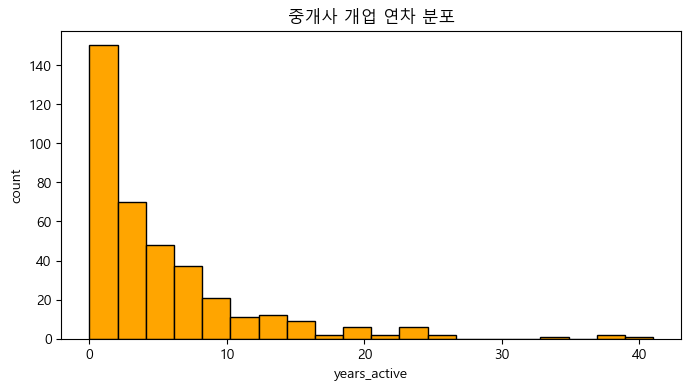

In [13]:
# 날짜로 변환
df["registDe"] = pd.to_datetime(df["registDe"], errors='coerce')

# 활동 연차 계산
df["years_active"] = pd.Timestamp.today().year - df["registDe"].dt.year

print("\n📈 years_active 기본 통계")
print(df["years_active"].describe())

# 히스토그램
plt.figure(figsize=(8, 4))
plt.hist(df["years_active"], bins=20, color='orange', edgecolor='black')
plt.title("중개사 개업 연차 분포")
plt.xlabel("years_active")
plt.ylabel("count")
plt.show()


상관계수: 0.051


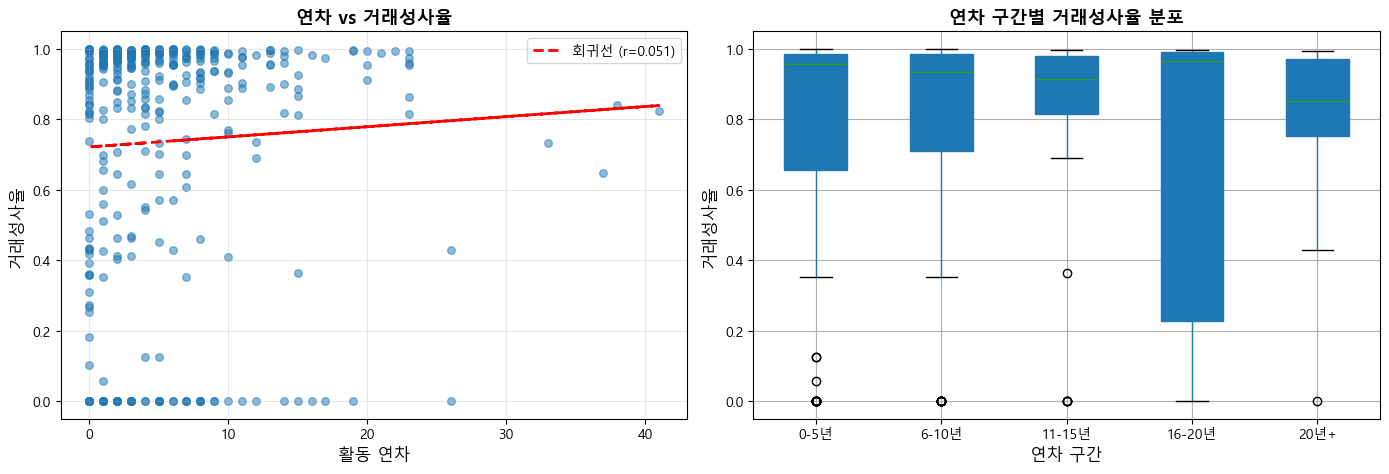

In [14]:
# 연차 vs 거래성사율 상관관계 분석

# 날짜 변환
df["registDe"] = pd.to_datetime(df["registDe"], errors='coerce')

# 활동 연차 계산
df["years_active"] = pd.Timestamp.today().year - df["registDe"].dt.year

# 상관계수 계산
correlation = df[["years_active", "거래성사율"]].corr().iloc[0, 1]
print(f"상관계수: {correlation:.3f}")

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Scatter plot with regression line
axes[0].scatter(df["years_active"], df["거래성사율"], alpha=0.5, s=30)
z = np.polyfit(df["years_active"], df["거래성사율"], 1)
p = np.poly1d(z)
axes[0].plot(df["years_active"], p(df["years_active"]), "r--", linewidth=2, label=f'회귀선 (r={correlation:.3f})')
axes[0].set_xlabel('활동 연차', fontsize=12)
axes[0].set_ylabel('거래성사율', fontsize=12)
axes[0].set_title('연차 vs 거래성사율', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# 2. Boxplot (연차 구간별)
df['연차구간'] = pd.cut(df['years_active'], bins=[0, 5, 10, 15, 20, 100], 
                        labels=['0-5년', '6-10년', '11-15년', '16-20년', '20년+'])
df.boxplot(column='거래성사율', by='연차구간', ax=axes[1], patch_artist=True)
axes[1].set_xlabel('연차 구간', fontsize=12)
axes[1].set_ylabel('거래성사율', fontsize=12)
axes[1].set_title('연차 구간별 거래성사율 분포', fontsize=13, fontweight='bold')
axes[1].get_figure().suptitle('')

plt.tight_layout()
plt.show()


## 컬럼 간 상관관계 분석

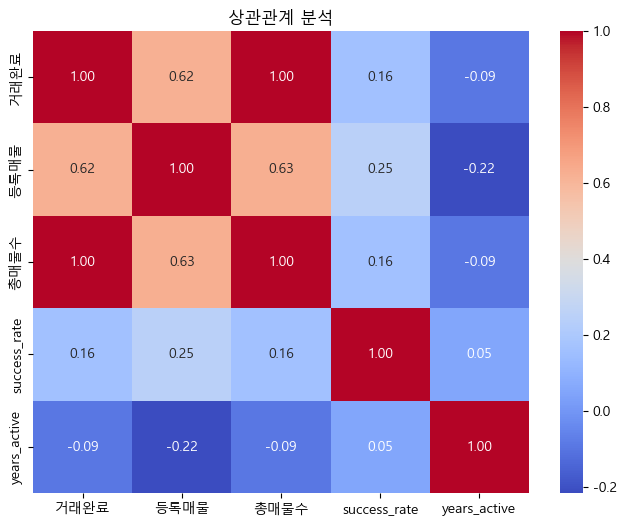

In [15]:
plt.figure(figsize=(8,6))
sns.heatmap(df[["거래완료","등록매물","총매물수","success_rate","years_active"]].corr(),
            annot=True, cmap="coolwarm", fmt=".2f")
plt.title("상관관계 분석")
plt.show()


## 지역별 분석

In [16]:
# 1. 지역별 기본 통계

if '거래성사율' not in df.columns:
    df['거래성사율'] = df['거래완료'] / (df['총매물수'] + 1)

region_stats = df.groupby('ldCodeNm').agg({
    '등록번호': 'count',
    '거래완료': ['mean', 'median', 'sum'],
    '총매물수': ['mean', 'median'],
    '거래성사율': ['mean', 'median']
}).round(2)

region_stats.columns = ['중개사수', '평균거래', '중앙거래', '총거래', '평균매물', '중앙매물', '평균성사율', '중앙성사율']
region_stats = region_stats.sort_values('평균성사율', ascending=False)

print("="*70)
print("지역별 통계")
print("="*70)
print(region_stats)

지역별 통계
            중개사수      평균거래   중앙거래      총거래      평균매물    중앙매물  평균성사율  중앙성사율
ldCodeNm                                                                  
서울특별시 중구       3    238.00  234.0      714    248.33   244.0   0.93   0.96
서울특별시 동작구     15   6821.20  988.0   102318   6887.00  1082.0   0.90   0.96
서울특별시 은평구     11   6890.55  168.0    75796   6915.73   186.0   0.88   0.90
서울특별시 마포구     14  33797.21  576.0   473161  33861.79   599.0   0.86   0.96
서울특별시 구로구      7   2139.57  874.0    14977   2194.14   990.0   0.84   0.96
서울특별시 강서구     32   7493.91  603.0   239805   7538.03   624.5   0.83   0.96
서울특별시 광진구     26   1080.50  286.0    28093   1105.88   293.0   0.79   0.94
서울특별시 영등포구    10   1880.30  933.5    18803   1916.00  1013.5   0.77   0.97
서울특별시 금천구     21  17257.86  810.0   362415  17328.95   845.0   0.76   0.96
서울특별시 강북구      7   2350.71  584.0    16455   2376.71   605.0   0.76   0.96
서울특별시 관악구     69  15736.74  816.0  1085835  15813.28   856.0   0.74   0.94
서울특별시 성동구      7  

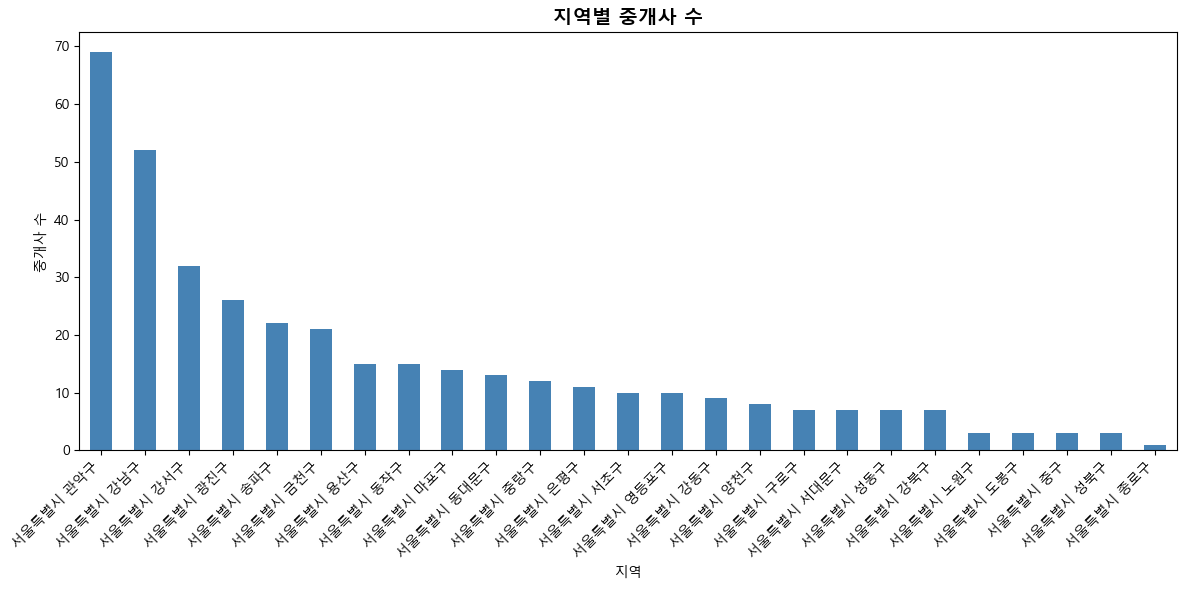

In [17]:
# 2. 시각화 - 지역별 중개사 수
plt.figure(figsize=(12, 6))
region_counts = df['ldCodeNm'].value_counts()
region_counts.plot(kind='bar', color='steelblue')
plt.title('지역별 중개사 수', fontsize= 14, fontweight='bold')
plt.xlabel('지역')
plt.ylabel('중개사 수')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

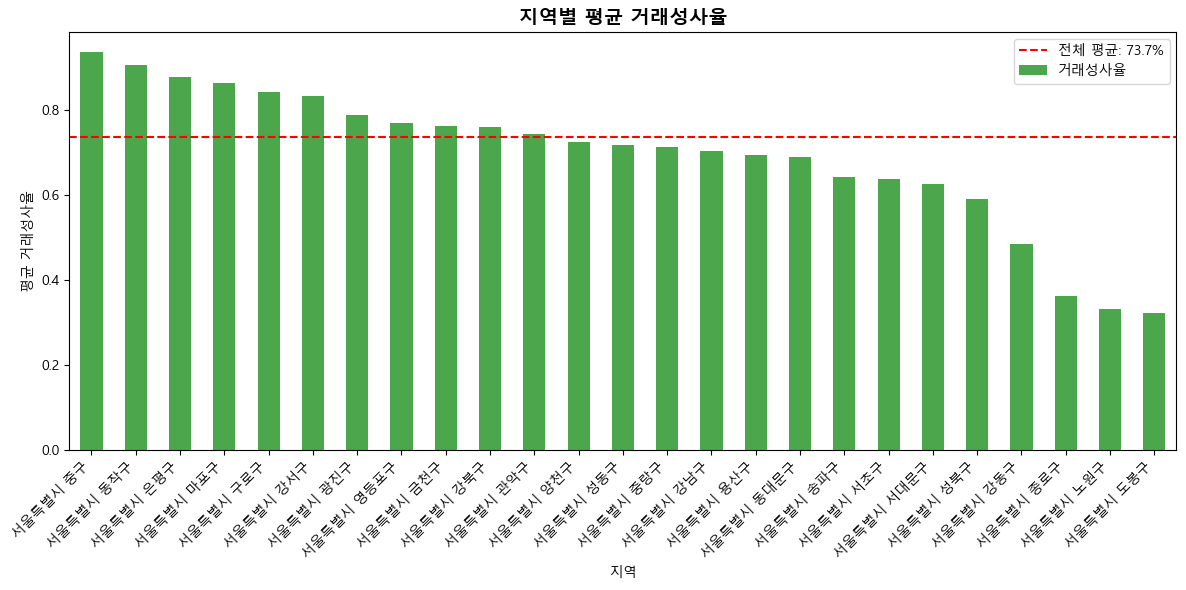

In [18]:
# 3. 시각화 - 지역별 평균 거래성사율
plt.figure(figsize=(12, 6))
region_success = df.groupby('ldCodeNm')['거래성사율'].mean().sort_values(ascending=False)
region_success.plot(kind='bar', color='green', alpha=0.7)
plt.title('지역별 평균 거래성사율', fontsize=14, fontweight='bold')
plt.xlabel('지역')
plt.ylabel('평균 거래성사율')
plt.axhline(df['거래성사율'].mean(), color='red', linestyle='--', label=f'전체 평균: {df["거래성사율"].mean():.1%}')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

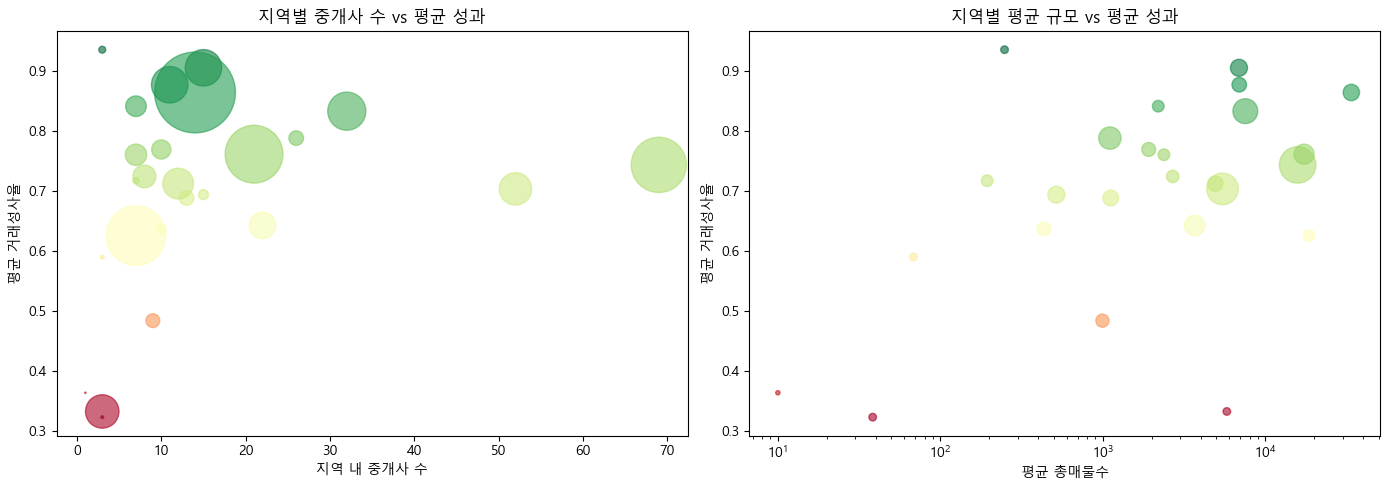

In [19]:
# 4. 지역별 규모 vs 성과
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 중개사 수 vs 평균 성과
region_summary = df.groupby('ldCodeNm').agg({
    '등록번호': 'count',
    '거래성사율': 'mean',
    '총매물수': 'mean'
})
region_summary.columns = ['중개사수', '평균성사율', '평균매물수']

axes[0].scatter(region_summary['중개사수'], region_summary['평균성사율'], 
                s=region_summary['평균매물수']/10, alpha=0.6, c=region_summary['평균성사율'], 
                cmap='RdYlGn')
axes[0].set_xlabel('지역 내 중개사 수')
axes[0].set_ylabel('평균 거래성사율')
axes[0].set_title('지역별 중개사 수 vs 평균 성과')

# 평균 매물수 vs 평균 성과
axes[1].scatter(region_summary['평균매물수'], region_summary['평균성사율'],
                s=region_summary['중개사수']*10, alpha=0.6, c=region_summary['평균성사율'],
                cmap='RdYlGn')
axes[1].set_xlabel('평균 총매물수')
axes[1].set_ylabel('평균 거래성사율')
axes[1].set_title('지역별 평균 규모 vs 평균 성과')
axes[1].set_xscale('log')

plt.tight_layout()
plt.show()

In [20]:
# 상호명이 같고 등록번호, 거래완료, 총매물수가 같은건 하나만 남기고 삭제하기

In [21]:
df["bsnmCmpnm"].nunique()

346

In [22]:
office_counts = df["bsnmCmpnm"].value_counts()

print("중복된 상호명 개수:", (office_counts > 1).sum())
print("\n상위 중복 상호명:")
print(office_counts[office_counts > 1].head(10))

# 중복된 상호명의 실제 데이터 확인
duplicated_offices = office_counts[office_counts > 1].index[:3]
for office in duplicated_offices:
    print(f"\n{'='*60}")
    print(f"상호명: {office}")
    print(df[df['bsnmCmpnm'] == office][['brkrNm', 'ldCodeNm', '등록번호', '거래완료', '총매물수']])


중복된 상호명 개수: 28

상위 중복 상호명:
bsnmCmpnm
바른공인중개사사무소      4
제일공인중개사사무소      3
이안공인중개사사무소      3
OK공인중개사사무소      3
에이스공인중개사사무소     3
대림공인중개사사무소      2
대경공인중개사사무소      2
수부동산공인중개사사무소    2
우주공인중개사사무소      2
행운공인중개사사무소      2
Name: count, dtype: int64

상호명: 바른공인중개사사무소
    brkrNm   ldCodeNm              등록번호  거래완료  총매물수
86     오의성  서울특별시 서초구  11650-2022-00036   441   452
87     신혜란  서울특별시 서초구  11650-2022-00036   441   452
88     최미나  서울특별시 서초구  11650-2022-00036   441   452
323    정철수  서울특별시 강남구    11680201500404   105   117

상호명: 제일공인중개사사무소
    brkrNm    ldCodeNm              등록번호  거래완료  총매물수
54     박지연   서울특별시 광진구  11215-2017-00103  3078  3087
55     박웅성   서울특별시 은평구  11380-2015-00100    90    99
254    유병직  서울특별시 영등포구  11560-2021-00120     0     0

상호명: 이안공인중개사사무소
    brkrNm   ldCodeNm              등록번호  거래완료  총매물수
30     이연진  서울특별시 서초구  11650-2019-00244     0     0
209    김순오  서울특별시 구로구  11320-2024-00017  5632  5673
210    안소영  서울특별시 강남구  11680-2025-00254  1200  1344


---

# 파생 피처 생성

In [23]:
# 0. 날짜 변환
df["registDe"] = pd.to_datetime(df["registDe"], errors='coerce')
df["estbsBeginDe"] = pd.to_datetime(df["estbsBeginDe"], errors='coerce')
df["estbsEndDe"] = pd.to_datetime(df["estbsEndDe"], errors='coerce')

In [24]:
# 1. 거래 효율성 피처
if '거래성사율' not in df.columns:
    df['거래성사율'] = df['거래완료'] / (df['총매물수'] + 1)
df['재고율'] = df['등록매물'] / (df['총매물수'] + 1)
df['거래재고비'] = df['거래완료'] / (df['등록매물'] + 1)

# 2. 규모 관련 피처
df['총매물수_로그'] = np.log1p(df['총매물수'])
df['안정구간여부'] = (df['총매물수'] >= 100).astype(int)
df['규모등급'] = pd.cut(df['총매물수'], 
                        bins=[0, 50, 100, 500, 1000, float('inf')],
                        labels=['초소형', '소형', '중형', '대형', '초대형'])


In [25]:
# 3. 시간 관련 피처
df['영업일수'] = (df['estbsEndDe'] - df['estbsBeginDe']).dt.days
df['등록일수'] = (pd.Timestamp.now() - df['registDe']).dt.days
df['영업년수'] = df['영업일수'] / 365
df['등록년수'] = df['등록일수'] / 365

In [26]:
# 4. 활동성 피처

df['일평균거래'] = df['거래완료'] / (df['영업일수'] + 1)
df['일평균매물'] = df['총매물수'] / (df['영업일수'] + 1)
df['연평균거래'] = df['거래완료'] / (df['영업년수'] + 1)

In [27]:
# 5. 지역 기반 피처
df['지역평균성사율'] = df.groupby('ldCodeNm')['거래성사율'].transform('mean')
df['지역대비성과'] = df['거래성사율'] - df['지역평균성사율']
df['지역평균매물수'] = df.groupby('ldCodeNm')['총매물수'].transform('mean')
df['지역내순위'] = df.groupby('ldCodeNm')['거래성사율'].rank(ascending=False, method='dense')

In [28]:
# 6. 연차 관련 피처
if 'years_active' not in df.columns:
    df['years_active'] = pd.Timestamp.today().year - df['registDe'].dt.year
    
df['경험등급'] = pd.cut(df['years_active'],
                        bins=[0, 5, 10, 15, 20, 100],
                        labels=['신규', '초급', '중급', '고급', '전문가'])

In [29]:
# 7. 성과 플래그
df['고성과플래그'] = ((df['거래성사율'] >= 0.95) & (df['총매물수'] >= 100)).astype(int)
df['저성과플래그'] = ((df['거래성사율'] < 0.5) & (df['총매물수'] >= 10)).astype(int)

In [30]:
# 8. 상호작용 피처
df['규모X지역평균'] = df['총매물수_로그'] * df['지역평균성사율']
df['연차X규모'] = df['years_active'] * df['총매물수_로그']

In [31]:
print(f"\n최종 데이터 shape: {df.shape}")
print(f"원본 컬럼: 13개")
print(f"생성된 피처: {df.shape[1] - 13}개")


최종 데이터 shape: (380, 39)
원본 컬럼: 13개
생성된 피처: 26개


백분위 기반 등급 분포
  D등급:  76개 ( 20.0%)
  C등급:  76개 ( 20.0%)
  B등급:  76개 ( 20.0%)
  A등급:  76개 ( 20.0%)
  S등급:  76개 ( 20.0%)

등급별 점수 범위:
                최소       최대      평균
trust_grade                        
D             20.1     26.5    22.1
C             26.6     55.4    36.1
B             57.6    175.2   104.5
A            180.4    751.3   380.3
S            801.6  81111.9  7628.2


C:\Users\Playdata\AppData\Local\Temp\ipykernel_980\918465637.py:30: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grade_ranges = df.groupby('trust_grade')['trust_score'].agg(['min', 'max', 'mean'])


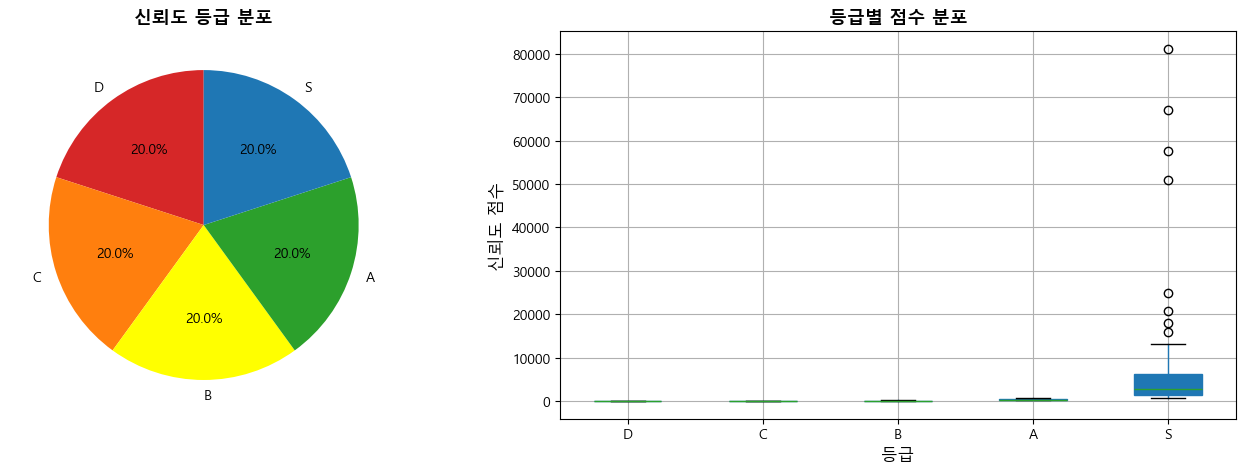


등급별 평균 특성
                평균점수  거래성사율      총매물수   재고율   일평균거래  영업년수
trust_grade                                              
D              22.13   0.19      9.99  0.39    0.01   1.0
C              36.10   0.63     79.07  0.35    0.15   1.0
B             104.54   0.91    419.86  0.08    1.07   1.0
A             380.29   0.96   1795.76  0.04    4.73   1.0
S            7628.22   0.99  37961.12  0.01  103.66   1.0

등급별 대표 중개사 (각 등급 상위 3개)

S등급:
  - 박수빈 (서울특별시 마포구): 81111.9점
  - 박찬미 (서울특별시 관악구): 67087.1점
  - 김동혁 (서울특별시 금천구): 57576.2점

A등급:
  - 방현철 (서울특별시 은평구): 751.3점
  - 엄서영 (서울특별시 송파구): 729.5점
  - 김미희 (서울특별시 영등포구): 711.6점

B등급:
  - 송주연 (서울특별시 광진구): 175.2점
  - 김미애 (서울특별시 영등포구): 174.0점
  - 박정수 (서울특별시 금천구): 171.0점

C등급:
  - 박만춘 (서울특별시 금천구): 55.4점
  - 김희자 (서울특별시 동대문구): 54.9점
  - 문정우 (서울특별시 강남구): 53.8점

D등급:
  - 정준흠 (서울특별시 강남구): 26.5점
  - 채방원 (서울특별시 용산구): 26.3점
  - 이재근 (서울특별시 강서구): 26.3점


C:\Users\Playdata\AppData\Local\Temp\ipykernel_980\918465637.py:58: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grade_features = df.groupby('trust_grade').agg({


In [35]:
# ============================================================================
# 백분위 기반 등급 분류
# ============================================================================

# 2. trust_score 계산 (가중치 기반)
df['trust_score'] = (
    df['거래성사율'] * 0.3 +
    df['총매물수'] * 0.2 +
    (100 - df['재고율']) * 0.2 +
    df['일평균거래'] * 0.15 +
    df['영업년수'] * 0.15
)

# 백분위 기반 등급 (각 등급이 비슷한 비율로 분포)
df['trust_grade'] = pd.qcut(df['trust_score'], 
                             q=5, 
                             labels=['D', 'C', 'B', 'A', 'S'],
                             duplicates='drop')

print("="*70)
print("백분위 기반 등급 분포")
print("="*70)
grade_dist = df['trust_grade'].value_counts().sort_index()
for grade, count in grade_dist.items():
    pct = count / len(df) * 100
    print(f"  {grade}등급: {count:3d}개 ({pct:5.1f}%)")

# 등급별 점수 범위
print("\n등급별 점수 범위:")
grade_ranges = df.groupby('trust_grade')['trust_score'].agg(['min', 'max', 'mean'])
grade_ranges.columns = ['최소', '최대', '평균']
print(grade_ranges.round(1))

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 등급별 분포 (파이 차트)
grade_counts = df['trust_grade'].value_counts().sort_index()
colors = ['#d62728', '#ff7f0e', '#ffff00', '#2ca02c', '#1f77b4']  # D=빨강, C=주황, B=노랑, A=초록, S=파랑
axes[0].pie(grade_counts, labels=grade_counts.index, autopct='%1.1f%%', 
            colors=colors, startangle=90)
axes[0].set_title('신뢰도 등급 분포', fontsize=13, fontweight='bold')

# 등급별 점수 박스플롯
df.boxplot(column='trust_score', by='trust_grade', ax=axes[1], patch_artist=True)
axes[1].set_xlabel('등급', fontsize=12)
axes[1].set_ylabel('신뢰도 점수', fontsize=12)
axes[1].set_title('등급별 점수 분포', fontsize=13, fontweight='bold')
axes[1].get_figure().suptitle('')

plt.tight_layout()
plt.show()

# 등급별 특성 비교
print("\n" + "="*70)
print("등급별 평균 특성")
print("="*70)
grade_features = df.groupby('trust_grade').agg({
    'trust_score': 'mean',
    '거래성사율': 'mean',
    '총매물수': 'mean',
    '재고율': 'mean',
    '일평균거래': 'mean',
    '영업년수': 'mean'
}).round(2)
grade_features.columns = ['평균점수', '거래성사율', '총매물수', '재고율', '일평균거래', '영업년수']
print(grade_features)

# 각 등급별 대표 중개사
print("\n" + "="*70)
print("등급별 대표 중개사 (각 등급 상위 3개)")
print("="*70)
for grade in ['S', 'A', 'B', 'C', 'D']:
    grade_df = df[df['trust_grade'] == grade].nlargest(3, 'trust_score')
    if len(grade_df) > 0:
        print(f"\n{grade}등급:")
        for idx, row in grade_df.iterrows():
            print(f"  - {row['brkrNm']} ({row['ldCodeNm']}): {row['trust_score']:.1f}점")


# 파생 피쳐 끝

## 학습에 쓸 데이터 준비

In [ ]:
# 타겟 변수
# 회귀: trust_score (0~100점 예측)
# 분류: trust_grade (S/A/B/C/D 예측)

# 사용할 피처 선택
feature_cols = [
    # 수치형 피처
    '총매물수_로그',
    '일평균거래',
    '연평균거래',
    '지역평균성사율',
    '지역대비성과',
    '지역내순위',
    '영업년수',
    '등록년수',
    '규모X지역평균',
    '연차X규모',
    '안정구간여부',
    
    # 카테고리 피처
    'ldCodeNm',
    '규모등급',
    '경험등급'
]

# 카테고리 vs 수치형 분리
categorical_features = ['ldCodeNm', '규모등급', '경험등급']
numerical_features = [col for col in feature_cols if col not in categorical_features]

print(f"수치형 피처: {len(numerical_features)}개")
print(numerical_features)
print(f"\n카테고리 피처: {len(categorical_features)}개")
print(categorical_features)


수치형 피처: 11개
['총매물수_로그', '일평균거래', '연평균거래', '지역평균성사율', '지역대비성과', '지역내순위', '영업년수', '등록년수', '규모X지역평균', '연차X규모', '안정구간여부']

카테고리 피처: 3개
['ldCodeNm', '규모등급', '경험등급']


## Train/Test Split

In [33]:
from sklearn.model_selection import train_test_split

# 회귀 문제로 진행 (점수 예측)
X = df[feature_cols]
y = df['trust_score']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train 점수 범위: {y_train.min():.1f} ~ {y_train.max():.1f}")
print(f"Test 점수 범위: {y_test.min():.1f} ~ {y_test.max():.1f}")


NameError: name 'feature_cols' is not defined

## 전처리 파이프라인

In [34]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features)
    ])

print("✓ 전처리 파이프라인 생성 완료")


NameError: name 'numerical_features' is not defined

## 모델 학습

In [ ]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

models = {
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'Ridge': Ridge(alpha=1.0)
}

results = {}

for name, model in models.items():
    # 파이프라인 생성
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', model)
    ])
    
    # 학습
    pipeline.fit(X_train, y_train)
    
    # 예측
    y_pred = pipeline.predict(X_test)
    
    # 평가
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    results[name] = {
        'MSE': mse,
        'RMSE': np.sqrt(mse),
        'MAE': mae,
        'R2': r2,
        'model': pipeline
    }
    
    print(f"\n{name}:")
    print(f"  RMSE: {np.sqrt(mse):.2f}")
    print(f"  MAE: {mae:.2f}")
    print(f"  R²: {r2:.3f}")

# 최고 성능 모델
best_model_name = max(results, key=lambda x: results[x]['R2'])
print(f"\n✓ 최고 성능 모델: {best_model_name} (R² = {results[best_model_name]['R2']:.3f})")



Random Forest:
  RMSE: 2.29
  MAE: 1.50
  R²: 0.989

Gradient Boosting:
  RMSE: 1.71
  MAE: 1.19
  R²: 0.994

Ridge:
  RMSE: 2.45
  MAE: 1.65
  R²: 0.988

✓ 최고 성능 모델: Gradient Boosting (R² = 0.994)


## 예측 결과 시각화

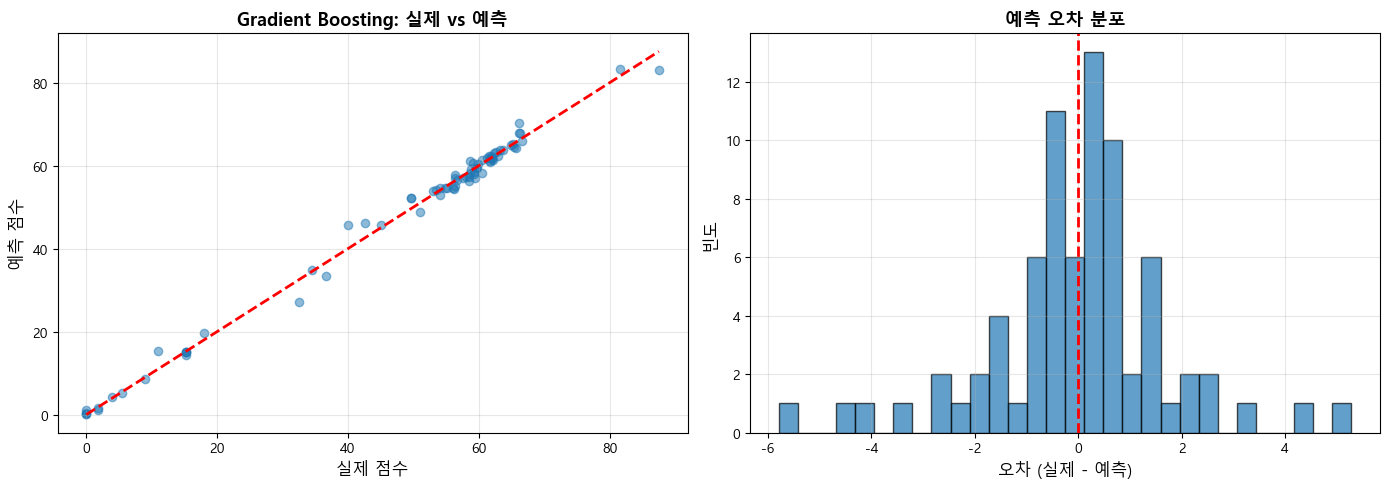

In [ ]:
best_model = results[best_model_name]['model']
y_pred = best_model.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 실제 vs 예측
axes[0].scatter(y_test, y_pred, alpha=0.5)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('실제 점수', fontsize=12)
axes[0].set_ylabel('예측 점수', fontsize=12)
axes[0].set_title(f'{best_model_name}: 실제 vs 예측', fontsize=13, fontweight='bold')
axes[0].grid(alpha=0.3)

# 오차 분포
errors = y_test - y_pred
axes[1].hist(errors, bins=30, edgecolor='black', alpha=0.7)
axes[1].axvline(0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('오차 (실제 - 예측)', fontsize=12)
axes[1].set_ylabel('빈도', fontsize=12)
axes[1].set_title('예측 오차 분포', fontsize=13, fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## Test 데이터로 모델 성능 확인

Gradient Boosting - Test 데이터 성능
RMSE (평균 오차):     1.71점
MAE (절대 오차):      1.19점
R² (결정계수):        0.994

해석:
  - 평균적으로 실제 점수와 ±1.2점 차이
  - 전체 분산의 99.4%를 설명

Test 데이터 샘플 (랜덤 10개)
     실제점수      예측점수        오차     절대오차 중개사명         지역 실제등급 예측등급
62.079670 61.488922  0.590749 0.590749  이금옥 서울특별시 영등포구    A    A
60.534240 58.200631  2.333609 2.333609  유재경  서울특별시 마포구    A    B
58.650331 58.317108  0.333223 0.333223  최경순  서울특별시 마포구    B    B
57.532090 57.039981  0.492109 0.492109  이양민  서울특별시 강남구    B    B
49.622543 52.201073 -2.578530 2.578530  정향숙  서울특별시 은평구    C    C
62.062824 61.825026  0.237798 0.237798  김진희  서울특별시 양천구    A    A
55.140016 54.670909  0.469107 0.469107  박웅성  서울특별시 은평구    B    B
42.613897 46.121581 -3.507683 3.507683  장윤주  서울특별시 마포구    C    C
56.709555 56.555778  0.153777 0.153777  김철호  서울특별시 광진구    B    B
40.013433 45.800412 -5.786979 5.786979  이승민  서울특별시 강동구    C    C

예측 오차가 큰 케이스 Top 5 (과대평가)
중개사명         지역      실제점수      예측점수       오차 실제등급 예측등급
 최채영  서울특별시 관악구 32.518842

C:\Users\Playdata\AppData\Local\Temp\ipykernel_30456\2346076636.py:41: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bins=df.groupby('trust_grade')['trust_score'].min().sort_values().values.tolist() + [100],


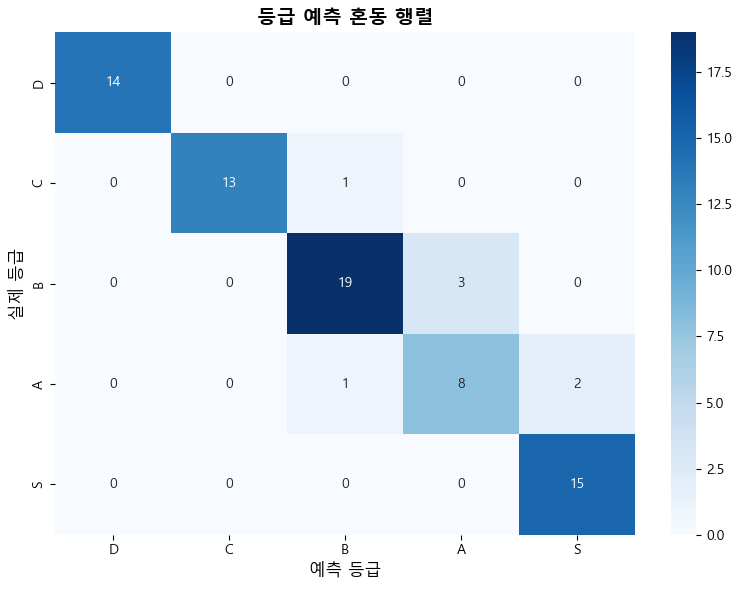


오차 통계
count    76.000000
mean     -0.032917
std       1.725535
min      -5.786979
25%      -0.661378
50%       0.154026
75%       0.758525
max       5.279833
Name: 오차, dtype: float64


In [ ]:
# 1. Test 데이터 예측
y_pred_test = best_model.predict(X_test)

# 2. 성능 지표 계산
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mse = mean_squared_error(y_test, y_pred_test)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred_test)
r2 = r2_score(y_test, y_pred_test)

print("="*70)
print(f"{best_model_name} - Test 데이터 성능")
print("="*70)
print(f"RMSE (평균 오차):     {rmse:.2f}점")
print(f"MAE (절대 오차):      {mae:.2f}점")
print(f"R² (결정계수):        {r2:.3f}")
print(f"\n해석:")
print(f"  - 평균적으로 실제 점수와 ±{mae:.1f}점 차이")
print(f"  - 전체 분산의 {r2*100:.1f}%를 설명")

# 3. Test 데이터 결과 상세 확인
test_results = pd.DataFrame({
    '실제점수': y_test.values,
    '예측점수': y_pred_test,
    '오차': y_test.values - y_pred_test,
    '절대오차': np.abs(y_test.values - y_pred_test)
})

# 원본 데이터 정보 추가
test_results['중개사명'] = df.loc[y_test.index, 'brkrNm'].values
test_results['지역'] = df.loc[y_test.index, 'ldCodeNm'].values
test_results['실제등급'] = df.loc[y_test.index, 'trust_grade'].values

# 예측 점수로 등급 부여
test_results['예측등급'] = pd.cut(test_results['예측점수'],
                                bins=df.groupby('trust_grade')['trust_score'].min().sort_values().values.tolist() + [100],
                                labels=['D', 'C', 'B', 'A', 'S'],
                                include_lowest=True)

print("\n" + "="*70)
print("Test 데이터 샘플 (랜덤 10개)")
print("="*70)
print(test_results.sample(10).to_string(index=False))

# 4. 오차가 큰 케이스 분석
print("\n" + "="*70)
print("예측 오차가 큰 케이스 Top 5 (과대평가)")
print("="*70)
worst_overpredict = test_results.nlargest(5, '오차')[['중개사명', '지역', '실제점수', '예측점수', '오차', '실제등급', '예측등급']]
print(worst_overpredict.to_string(index=False))

print("\n" + "="*70)
print("예측 오차가 큰 케이스 Top 5 (과소평가)")
print("="*70)
worst_underpredict = test_results.nsmallest(5, '오차')[['중개사명', '지역', '실제점수', '예측점수', '오차', '실제등급', '예측등급']]
print(worst_underpredict.to_string(index=False))

# 5. 등급 일치율
grade_match = (test_results['실제등급'] == test_results['예측등급']).sum()
grade_accuracy = grade_match / len(test_results) * 100

print("\n" + "="*70)
print("등급 예측 정확도")
print("="*70)
print(f"등급 일치: {grade_match}/{len(test_results)} ({grade_accuracy:.1f}%)")

# 등급별 혼동 행렬
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(test_results['실제등급'], test_results['예측등급'], 
                      labels=['D', 'C', 'B', 'A', 'S'])

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['D', 'C', 'B', 'A', 'S'],
            yticklabels=['D', 'C', 'B', 'A', 'S'])
plt.xlabel('예측 등급', fontsize=12)
plt.ylabel('실제 등급', fontsize=12)
plt.title('등급 예측 혼동 행렬', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 6. 오차 통계
print("\n" + "="*70)
print("오차 통계")
print("="*70)
print(test_results['오차'].describe())


## SHAP으로 피처 중요도 분석

In [ ]:
# SHAP 설치 (필요시)
!pip install shap

import shap

# 1. SHAP Explainer 생성
# 전처리된 데이터 준비
X_train_transformed = best_model.named_steps['preprocessor'].transform(X_train)
X_test_transformed = best_model.named_steps['preprocessor'].transform(X_test)

# 피처 이름 가져오기
feature_names = (numerical_features + 
                 list(best_model.named_steps['preprocessor']
                      .named_transformers_['cat']
                      .get_feature_names_out(categorical_features)))

print(f"전처리 후 피처 수: {len(feature_names)}개")

# Explainer 생성 (Gradient Boosting용)
explainer = shap.TreeExplainer(best_model.named_steps['regressor'])
shap_values = explainer.shap_values(X_test_transformed)

print("✓ SHAP 값 계산 완료")


   ---------------------------------------- 0.0/549.1 kB ? eta -:--:--
   ---------------------------------------- 549.1/549.1 kB 4.4 MB/s  0:00:00
   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   ------------------------------ --------- 2.1/2.7 MB 10.3 MB/s eta 0:00:01
   ---------------------------------------- 2.7/2.7 MB 9.4 MB/s  0:00:00
   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
   -- ------------------------------------- 2.4/38.1 MB 11.4 MB/s eta 0:00:04
   ---- ----------------------------------- 4.5/38.1 MB 10.8 MB/s eta 0:00:04
   ----- ---------------------------------- 5.5/38.1 MB 9.7 MB/s eta 0:00:04
   ------ --------------------------------- 5.8/38.1 MB 7.4 MB/s eta 0:00:05
   ------ --------------------------------- 6.0/38.1 MB 5.8 MB/s eta 0:00:06
   ------ --------------------------------- 6.0/38.1 MB 5.8 MB/s eta 0:00:06
   ------ --------------------------------- 6.0/38.1 MB 5.8 MB/s eta 0:00:06
   ------ ------------


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip
c:\Users\Playdata\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


전처리 후 피처 수: 45개
✓ SHAP 값 계산 완료


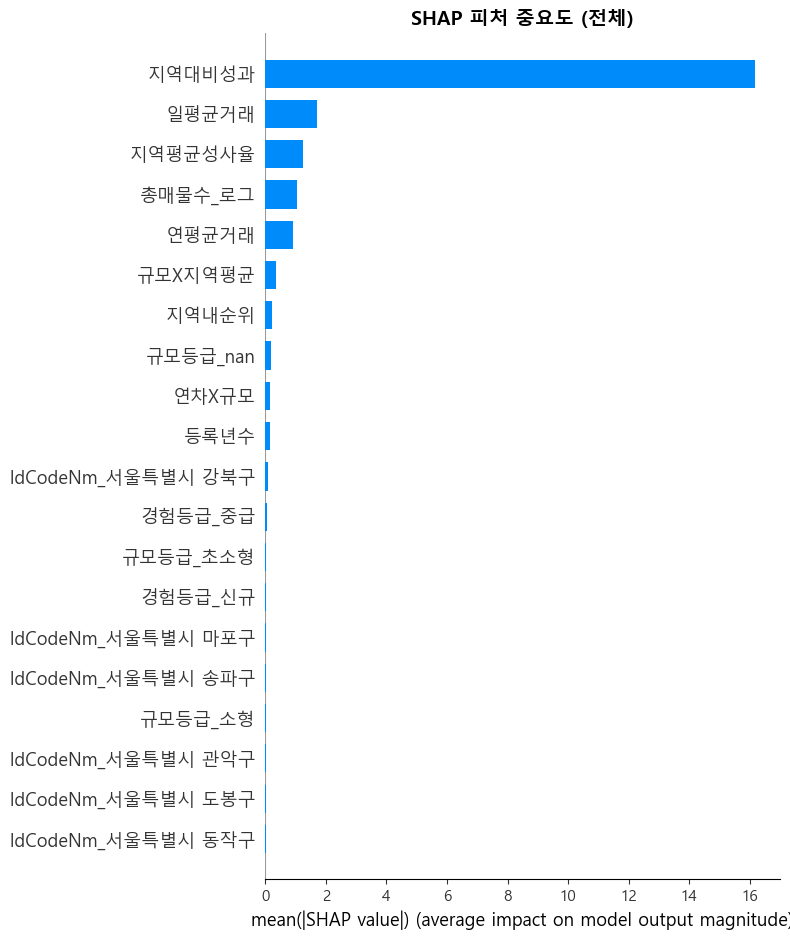

In [ ]:
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_transformed, 
                  feature_names=feature_names,
                  plot_type="bar",
                  show=False)
plt.title('SHAP 피처 중요도 (전체)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
